importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importing DataSets

In [ ]:
death = pd.read_csv('C:\\Users\\Malik Gee\\Desktop\\Pandas For DataScience\\02_Pandas_DataFrame\\datasets-session-21\\time_series_covid19_deaths_global.csv')
confirm = pd.read_csv('C:\\Users\\Malik Gee\\Desktop\\Pandas For DataScience\\02_Pandas_DataFrame\\datasets-session-21\\time_series_covid19_confirmed_global.csv')

can we have multiple index Series? let's try

In [ ]:
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
a = pd.Series([1,2,3,4,5,6,7,8],index=index_val)
# there is a problem in this multiindex series.

In [ ]:
# Solution
# 1. pd.multiindex.from tuples()
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
multiindex.levels[1]
# 2. pd.multiindex.from product()
pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]])

In [ ]:
# Creating series with multiindex object
s = pd.Series([1,2,3,4,5,6,7,8],index=multiindex)

In [ ]:
# how to fetch items from such a series.
s[('cse',2022)]
s['cse']

logical questios to ask.

In [ ]:
# Unstack
temp = s.unstack()

In [ ]:
# stack
temp.stack()

MultiIndex DataFrame

In [ ]:
branch_df1 = pd.DataFrame([
    [1,2],
    [3,4],
    [5,6],
    [7,8],
    [9,10],
    [11,12],
    [13,14],
    [15,16]
],index=multiindex,columns=['avg_package','students'])

branch_df1

In [ ]:
# Are coloumns are really different from index?
# MultiIndex df from coloumns prospective.
branch_df2 = pd.DataFrame([
    [1,2,0,0],
    [3,4,0,0],
    [5,6,0,0],
    [7,8,0,0],
],
index=[2019,2020,2021,2022],
    columns=pd.MultiIndex.from_product([['dehli','Mumbai'],['avg_package','students']])
    )

branch_df2['dehli']


In [ ]:
# MultiIndex df in terms of both cols and index.
branch_df3 = pd.DataFrame([
    [1,2,0,0],
    [3,4,0,0],
    [5,6,0,0],
    [7,8,0,0],
    [9,10,0,0],
    [11,12,0,0],
    [13,14,0,0],
    [15,16,0,0],
],
index=multiindex,
    columns=pd.MultiIndex.from_product([['dehli','Mumbai'],['avg_package','students']])
    )

branch_df3

Stacking and Unstacking

In [ ]:
branch_df1.unstack().stack()

branch_df3.unstack()

            Working with multi-index DataFrames

In [ ]:
# head and tail
branch_df3.head()
branch_df3.tail()
# shape
branch_df3.shape
# info
branch_df3.info()
# duplicates
branch_df3.duplicated()
# is null
branch_df3.isnull()

In [ ]:
# Extracting Single rows
branch_df3.loc[('cse',2022)]

In [ ]:
# Extracting multiple rows using loc
branch_df3.loc[('cse',2019):('ece',2020):2]
# Extracting multiple rows using iloc
branch_df3.iloc[0:5:2]
# Extracting both rows coloumns using iloc
branch_df3.iloc[[0,4],[1,2]]

In [ ]:
# swap level row wise 
branch_df3.swaplevel()
# swap level col wise
branch_df3.swaplevel(axis=1)

            Melt() / Convert wide data format into Long data format.

In [ ]:
# wide to Long
# Simple example
pd.DataFrame({'cse':[120]}).melt()
#branch with yaar!
pd.DataFrame({'cse':[120],'ece':[100],'mech':[50]}).melt(var_name='branch',value_name='num_std')

pd.DataFrame({
    'branch':['cse','ece','mec'],
    '2020':[100,150,50],
    '2021':[102,145,78],
    '2022':[144,115,145],
}).melt(id_vars=['branch'],var_name='year',value_name='students')

            melt() with Real-world example

In [ ]:
death = death.melt(id_vars=['Province/State','Country/Region','Lat','Long'],var_name='date',value_name='num_deaths')
confirm = confirm.melt(id_vars=['Province/State','Country/Region','Lat','Long'],var_name='date',value_name='num_cases')

both_merged = confirm.merge(death,on=['Province/State','Country/Region','Lat','Long','date'])
both_merged[['Country/Region','date','num_cases','num_deaths']]

            pivot() / Convert long data format into wide data format.

In [ ]:
# find out total bill per category(male / female)
df = sns.load_dataset('tips')
df.groupby('sex')['total_bill'].mean()

In [ ]:
# find out total bill per (male / female) and (smoker / Yes /no ) and also extract only male
df4 = df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()
df4.loc['Male',('total_bill','Yes')]

Now we use pivot table instead of this to find this questions in easyway.

In [ ]:
df.pivot_table(index='sex',columns='smoker',values='total_bill')

In [ ]:
# aggfunc
df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='count')

multidimensional analysis

In [299]:
df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc={'size':'mean','tip':'max','total_bill':'sum'}) 

size                                               tip  \
day                Thur              Fri              Sat       Sun  Thur   
time              Lunch Dinner     Lunch Dinner    Dinner    Dinner Lunch   
sex    smoker                                                               
Male   Yes     2.300000    NaN  1.666667    2.4  2.629630  2.600000  5.00   
       No      2.500000    NaN       NaN    2.0  2.656250  2.883721  6.70   
Female Yes     2.428571    NaN  2.000000    2.0  2.200000  2.500000  5.00   
       No      2.500000    2.0  3.000000    2.0  2.307692  3.071429  5.17   

                                                total_bill                \
day                    Fri           Sat    Sun       Thur           Fri   
time          Dinner Lunch Dinner Dinner Dinner      Lunch Dinner  Lunch   
sex    smoker                                                              
Male   Yes       NaN  2.20   4.73  10.00    6.5     191.71    NaN  34.16   
       No        NaN   NaN   3.50   9.00    6.0     369.73    NaN    NaN   
Female Yes       NaN  3.48   4.30   6.50    4.0     134.53    NaN  39.78   
       No        3.0  3.00   3.25   4.67    5.2     381.58  18.78  15.98   

                                       
day                       Sat     Sun  
time           Dinner  Dinner  Dinner  
sex    smoker                          
Male   Yes     129.46  589.62  392.12  
       No       34.95  637.73  877.34  
Female Yes      48.80  304.00   66.16  
       No       22.75  247.05  291.54

In [300]:
# margins
df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum',margins=True)

smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


Ploting graphs

In [301]:
df = pd.read_csv('C:\\Users\\Malik Gee\\Desktop\\Pandas For DataScience\\02_Pandas_DataFrame\\datasets-session-22\\expense_data.csv')

In [305]:
df['Category'].value_counts()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    str    
 1   Account         277 non-null    str    
 2   Category        277 non-null    str    
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    str    
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    str    
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    str    
 10  Account.1       277 non-null    float64
dtypes: float64(5), str(6)
memory usage: 23.9 KB


Extracting Date and time from the dataframe

In [308]:
df['Date'] = pd.to_datetime(df['Date'])

Now Extracting Month from the dataframe

In [315]:
df['month'] = df['Date'].dt.month_name()

<Axes: xlabel='month'>

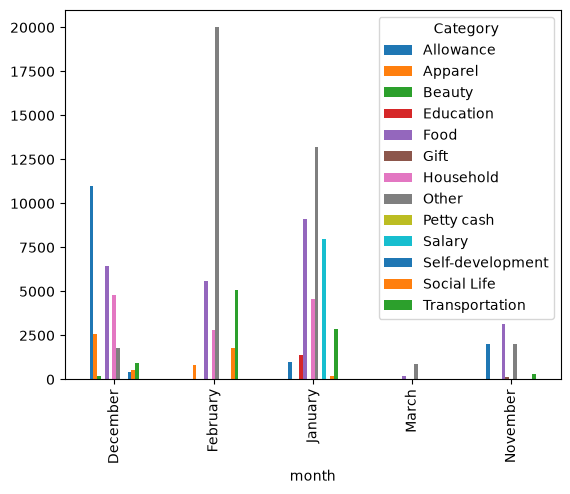

In [324]:
df.pivot_table(index='month',columns='Category',values='INR',aggfunc='sum',fill_value=0).plot(kind='bar')

<Axes: xlabel='month'>

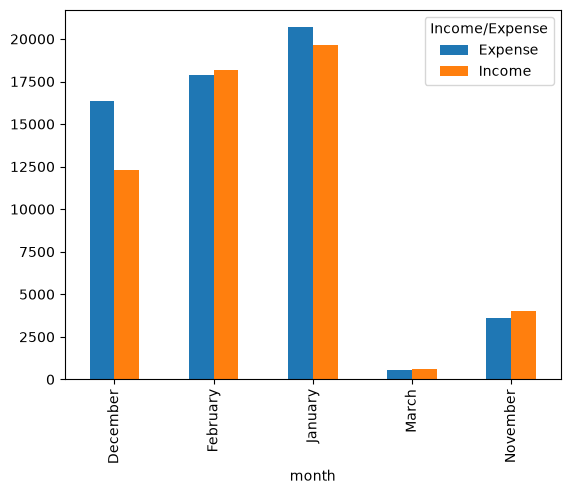

In [325]:
df.pivot_table(index='month',columns='Income/Expense',values='INR',aggfunc='sum',fill_value=0).plot(kind='bar')